# Multirotor kinematics

The multirotor is a **holonomic point mass**: its velocity can point in any direction and change in a single bounded step, it can slow, stop, and hover, and its nose heading (`yaw`) is decoupled from travel — it can look one way while flying another. We drive the real `Multirotor` under the DJI M600 envelope (`v_max` 18 m/s, `a_x` 5 m/s², yaw rate 90 °/s) and read a `MotionCommand`, a PX4-style setpoint whose channels the model reads selectively.

This notebook generates the figures on the *Multirotor* module page. Every case drives the model from a hover with the same one-line step; the grey arrows are the nose (`yaw`), sampled along the track, so where they leave the path the facing and travel are decoupled.

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 130

from opencdarr import geo
from opencdarr.kinematics import Multirotor, MotionCommand
from opencdarr.performance import M600
from opencdarr.state import AircraftState

DT = 0.5
LAT0, LON0 = 52.0, 4.0
kinematics = Multirotor()

def hover(yaw=None):
    return AircraftState(id="M600", lat=LAT0, lon=LON0, trk=0.0, gs=0.0, yaw=yaw)

def cruise(trk, gs):
    return AircraftState(id="M600", lat=LAT0, lon=LON0, trk=trk, gs=gs)

def simulate(s0, command, t_max):
    # advance from s0 under a constant command; return the list of states
    states, s, t = [s0], s0, 0.0
    while t < t_max:
        s = kinematics.step(s, command, M600, DT)
        states.append(s)
        t += DT
    return states

def enu(s):
    qdr, dist = geo.qdrdist(LAT0, LON0, s.lat, s.lon)
    r = math.radians(qdr)
    return dist * math.sin(r), dist * math.cos(r)

def plot_case(ax, states, title, arrow=14.0):
    # ground track (blue) with a grey nose (yaw) arrow every 1.5 s
    pts = [enu(s) for s in states]
    xs, ys = [p[0] for p in pts], [p[1] for p in pts]
    ax.plot(xs, ys, color="#1f77b4", lw=2.0, zorder=2)
    ax.plot(xs[0], ys[0], "^", color="#1f77b4", ms=8, zorder=4)
    lim_x, lim_y = list(xs), list(ys)
    for k in range(0, len(states), 3):
        head = states[k].yaw if states[k].yaw is not None else states[k].trk
        r = math.radians(head)
        tip = (pts[k][0] + math.sin(r) * arrow, pts[k][1] + math.cos(r) * arrow)
        ax.annotate("", xy=tip, xytext=pts[k], arrowprops=dict(arrowstyle="->", color="#888888", lw=1.3))
        lim_x.append(tip[0]); lim_y.append(tip[1])
    cx, cy = (min(lim_x) + max(lim_x)) / 2, (min(lim_y) + max(lim_y)) / 2
    half = max(max(lim_x) - min(lim_x), max(lim_y) - min(lim_y)) / 2
    half = max(half, 10.0) * 1.15
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
    ax.set_title(title, fontsize=10); ax.set_xlabel("east [m]"); ax.set_ylabel("north [m]")
    ax.set_aspect("equal")

def show_row(entries, figsize=(12.5, 4.4)):
    # entries: list of (s0, command, t_max, title) -> one subplot each, rendered inline
    fig, axs = plt.subplots(1, len(entries), figsize=figsize)
    axs = axs if len(entries) > 1 else [axs]
    for ax, (s0, command, t_max, title) in zip(axs, entries):
        plot_case(ax, simulate(s0, command, t_max), title)
    fig.tight_layout(); plt.show()

## Inertial velocity — `target_velocity`

An inertial ground velocity is a world-frame vector, so the yaw does not steer it. All three commands fly due north at 15 m/s; only the nose changes.

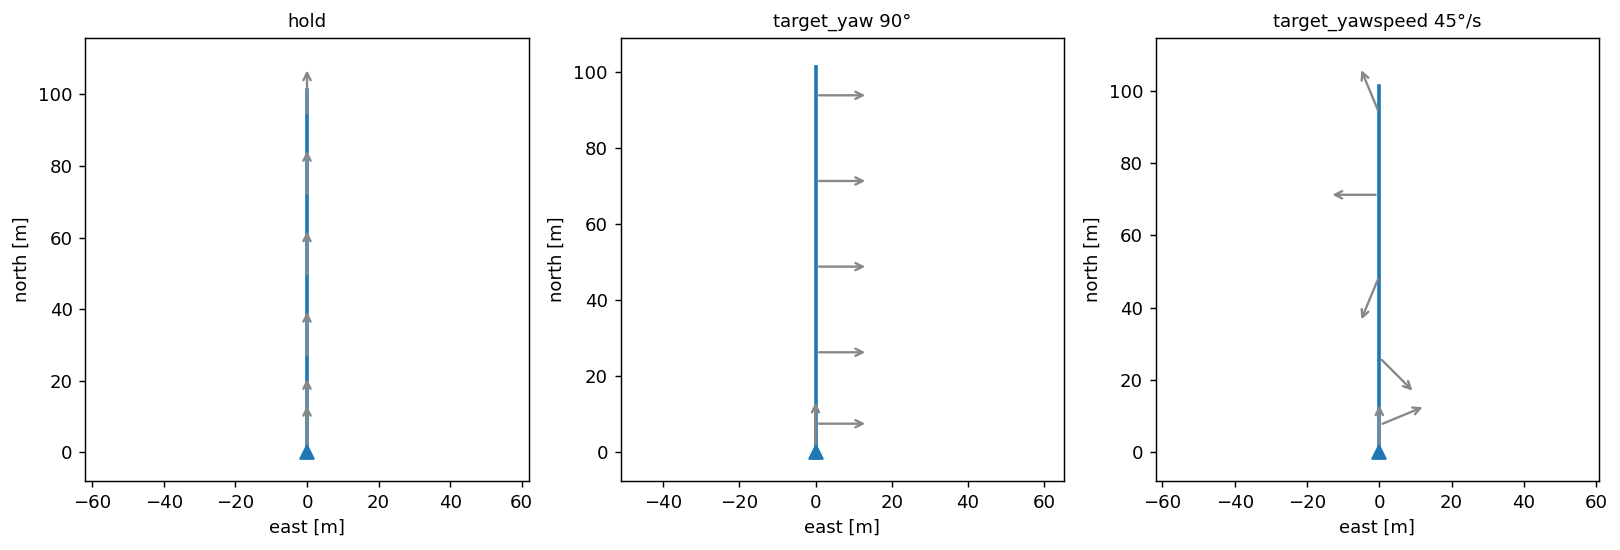

In [2]:
show_row([
    (hover(), MotionCommand(target_velocity=(0.0, 15.0)),                       8.0, "hold"),
    (hover(), MotionCommand(target_velocity=(0.0, 15.0), target_yaw=90.0),      8.0, "target_yaw 90°"),
    (hover(), MotionCommand(target_velocity=(0.0, 15.0), target_yawspeed=45.0), 8.0, "target_yawspeed 45°/s"),
])

## Body velocity — `target_body_velocity`

Body forward is along the nose, so here the yaw **does** steer the travel. The same three yaw modes now change the path: a straight line, a turn to east, and a circle.

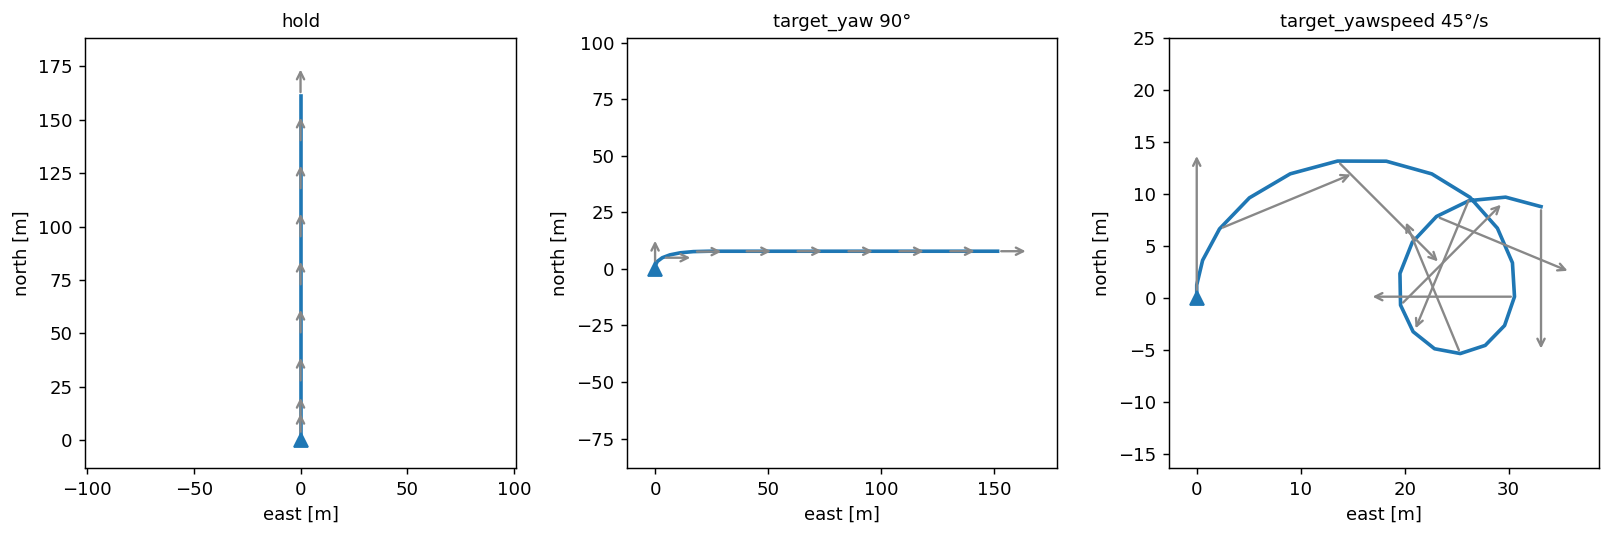

In [3]:
show_row([
    (hover(0.0), MotionCommand(target_body_velocity=(15.0, 0.0)),                       12.0, "hold"),
    (hover(0.0), MotionCommand(target_body_velocity=(15.0, 0.0), target_yaw=90.0),      12.0, "target_yaw 90°"),
    (hover(0.0), MotionCommand(target_body_velocity=(15.0, 0.0), target_yawspeed=45.0), 12.0, "target_yawspeed 45°/s"),
])

## Position — `target_position`

A position command flies to a point and hovers. Like inertial velocity, the path is yaw-independent and the yaw only turns the nose. The target is a point 130 m out on bearing 040.

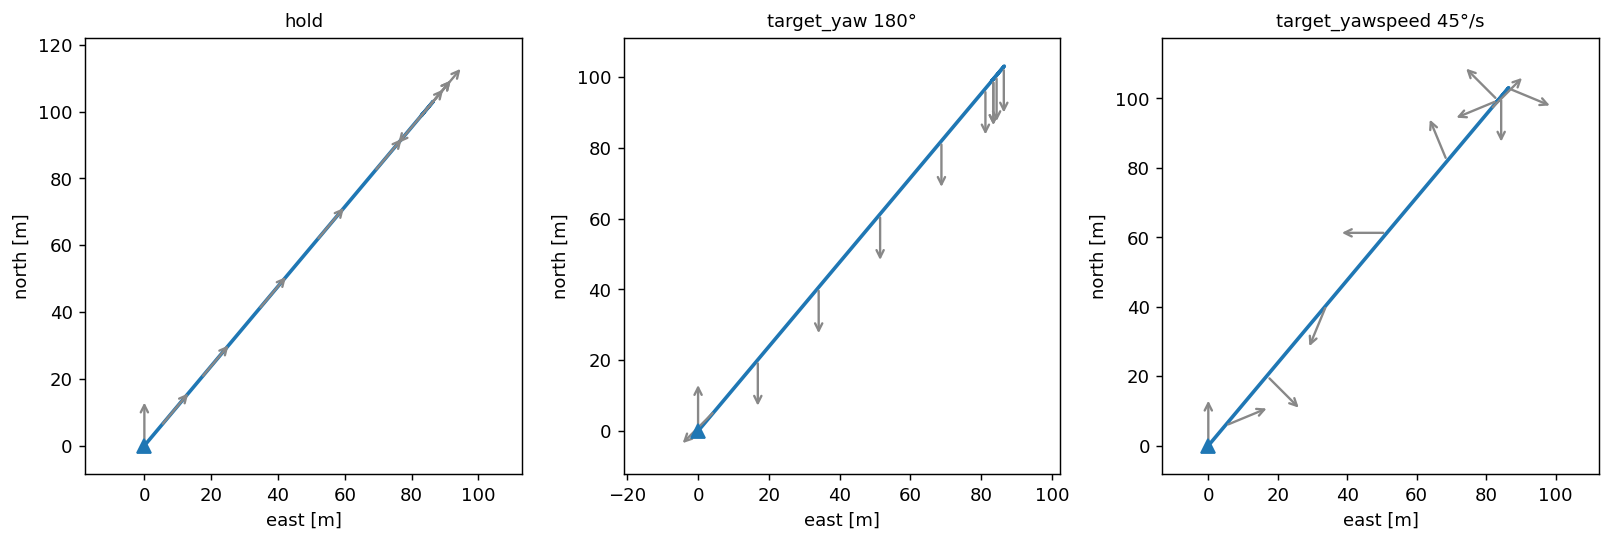

In [4]:
goto = geo.forward(LAT0, LON0, 40.0, 130.0)
show_row([
    (hover(), MotionCommand(target_position=goto),                        16.0, "hold"),
    (hover(), MotionCommand(target_position=goto, target_yaw=180.0),      16.0, "target_yaw 180°"),
    (hover(), MotionCommand(target_position=goto, target_yawspeed=45.0),  16.0, "target_yawspeed 45°/s"),
])

## Edge cases

When more than one translation channel is set, the priority order (position > body-velocity > inertial velocity) decides. A zero velocity is a valid command that decelerates to a hover.

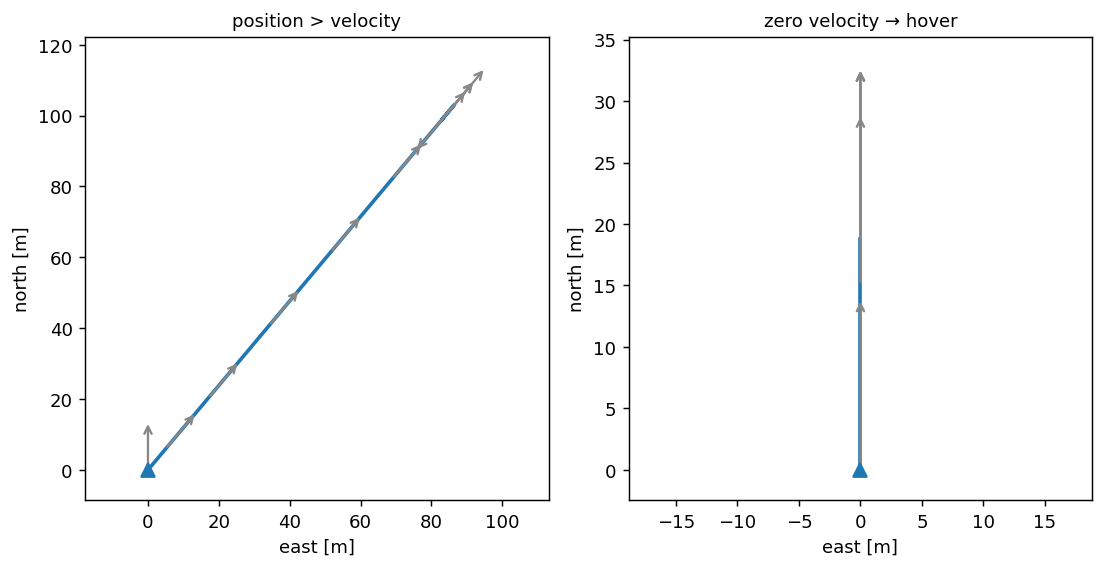

In [5]:
show_row([
    (hover(),           MotionCommand(target_position=goto, target_velocity=(15.0, 0.0)), 16.0, "position > velocity"),
    (cruise(0.0, 15.0), MotionCommand.from_velocity(0.0, 0.0),                            6.0,  "zero velocity → hover"),
], figsize=(8.6, 4.4))

## An under-specified command is an error

A command carrying no channel this vehicle can use is a programming error, and the model says so rather than guessing.

In [6]:
try:
    kinematics.step(hover(), MotionCommand(), M600, DT)
except ValueError as e:
    print(e)

MotionCommand has no target_velocity: this channel requires a ground-velocity vector (v_east/v_north/gs/trk are derived from it). An under-specified command for this vehicle is a programming error.
